![KAUST Academy](https://i.imgur.com/a3uAqnb.png)

# CLIP Zero-Shot and Fine-Tuning

**Scenario:** You are entering an image classification competition. The dataset has 102 classes of flowers -- far too many to label from scratch. But you have CLIP, a model that already understands both images and text. Can you classify flowers without ANY training? And how much better can you get with just a tiny amount of fine-tuning?

You will:
1. Use CLIP for **zero-shot classification** -- no training at all!
2. Improve accuracy with **prompt engineering** -- the art of asking CLIP the right question
3. Fine-tune CLIP push accuracy from ~67% to ~90% with minimal compute
4. Build an **image retrieval system** -- search images with natural language

| What You'll Learn | Why It Matters |
|---|---|
| Zero-shot classification | Classify anything without training -- useful when you have no labeled data |
| Prompt engineering | Small text changes = big accuracy gains (free performance!) |
| Prompt ensembling | Combine multiple prompts for more robust predictions |
| Text-to-image retrieval | Build a search engine in 10 lines of code |

In [ ]:
!pip install open_clip_torch peft -q
!pip uninstall -y torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.4 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

import open_clip

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import json
import urllib.request

plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


---
# Load CLIP and the Dataset

We use **OpenCLIP** (open-source CLIP) with a ViT-B/32 backbone. This model was trained on 400M image-text pairs from the internet -- it has seen descriptions of almost everything.

Our dataset is **Flowers-102**: 102 fine-grained flower species. This is a HARD dataset because many flowers look similar (different types of orchids, different types of daisies, etc.).

In [ ]:
model_name = 'ViT-B-32'
pretrained = 'laion2b_s34b_b79k'

clip_model, _, preprocess = open_clip.create_model_and_transforms(
    model_name, pretrained=pretrained
)
tokenizer = open_clip.get_tokenizer(model_name)

clip_model = clip_model.to(device)
clip_model.eval()

print(f'Model: {model_name}')
print(f'Parameters: {sum(p.numel() for p in clip_model.parameters()):,}')
print(f'Image input size: 224x224')
print(f'Embedding dimension: 512')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Model: ViT-B-32
Parameters: 151,277,313
Image input size: 224x224
Embedding dimension: 512


In [ ]:
# Download class names
url = 'https://gist.githubusercontent.com/JosephKJ/94c7728ed1a8e0cd87fe6a029769cde1/raw/403325f5110cb0f3099734c5edb9f457539c77e9/Oxford-102_Flower_dataset_labels.txt'
urllib.request.urlretrieve(url, 'flower_labels.txt')

with open('flower_labels.txt') as f:
    class_names = [line.strip() for line in f.readlines()]

print(f'Number of classes: {len(class_names)}')
print(f'First 10 classes: {class_names[:10]}')
print(f'Last 10 classes:  {class_names[-10:]}\n')
print()

# Load datasets
flowers_train = torchvision.datasets.Flowers102(
    root='./data', split='train', download=True, transform=preprocess
)
flowers_val = torchvision.datasets.Flowers102(
    root='./data', split='val', download=True, transform=preprocess
)
flowers_test = torchvision.datasets.Flowers102(
    root='./data', split='test', download=True, transform=preprocess
)

print(f'Train: {len(flowers_train)} images')
print(f'Val:   {len(flowers_val)} images')
print(f'Test:  {len(flowers_test)} images')

Number of classes: 102
First 10 classes: ["'pink primrose'", "'hard-leaved pocket orchid'", "'canterbury bells'", "'sweet pea'", "'english marigold'", "'tiger lily'", "'moon orchid'", "'bird of paradise'", "'monkshood'", "'globe thistle'"]
Last 10 classes:  ["'ball moss'", "'foxglove'", "'bougainvillea'", "'camellia'", "'mallow'", "'mexican petunia'", "'bromelia'", "'blanket flower'", "'trumpet creeper'", "'blackberry lily'"]


Train: 1020 images
Val:   1020 images
Test:  6149 images


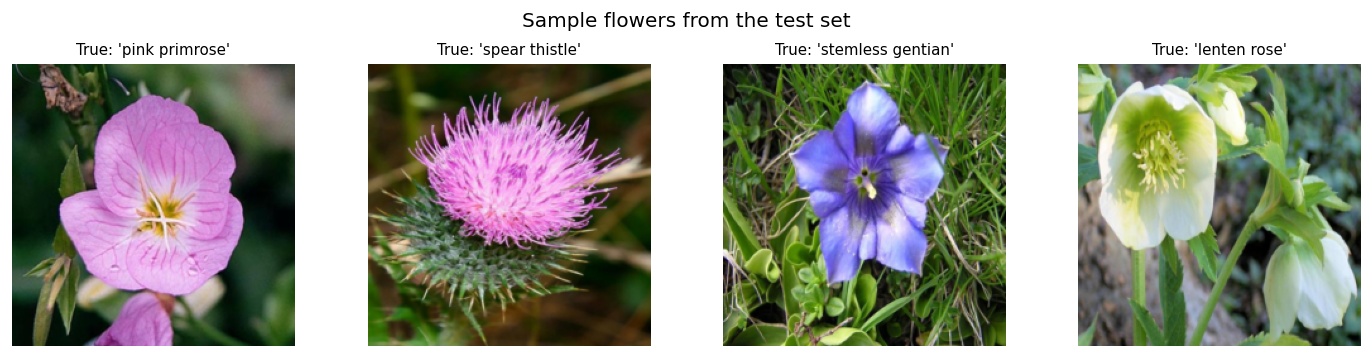

In [ ]:
# Load a raw image for display
flowers_raw = torchvision.datasets.Flowers102(
    root='./data', split='test', download=True,
    transform=transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
)

# Pick 4 test images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    img_raw, label = flowers_raw[i * 500]
    ax.imshow(img_raw.permute(1, 2, 0))
    ax.set_title(f'True: {class_names[label]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Sample flowers from the test set', fontsize=12)
plt.tight_layout()
plt.show()

---
# Zero-Shot Classification

The idea is simple:
1. Encode all 102 class names as text embeddings
2. Encode a test image as an image embedding
3. Find which class name is most similar to the image

No training needed! CLIP already knows what these flowers look like because it saw image-text pairs on the internet.

In [ ]:
# TASK 1: Zero-shot classification

# Create text embeddings for all 102 flower classes.
# Use the simple prompt: "a photo of a {class_name}"

# Create text prompts for each class
text_prompts = [f"a photo of a {name}" for name in class_names]

# Tokenize and encode
with torch.no_grad():
    text_tokens = tokenizer(text_prompts).to(device)
    text_embeddings = clip_model.encode_text(text_tokens)
    # Normalize to unit length (so dot product = cosine similarity)
    # dim=1 -> normalize along the embedding axis, per row
    text_embeddings = F.normalize(text_embeddings, dim=1)

print(f'Text embeddings shape: {text_embeddings.shape}')  # Should be (102, 512)

Text embeddings shape: torch.Size([102, 512])


In [ ]:
# Evaluate zero-shot accuracy on the test set

test_loader = DataLoader(flowers_test, batch_size=128, shuffle=False, num_workers=2)

correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Zero-shot eval'):
        images = images.to(device)
        labels = labels.to(device)

        # Encode images
        image_embeddings = clip_model.encode_image(images)
        image_embeddings = F.normalize(image_embeddings, dim=1)

        # Compute similarity: each image vs all 102 class texts
        # (batch, 512) @ (512, 102) = (batch, 102)
        similarity = image_embeddings @ text_embeddings.T

        # Predict = class with highest similarity
        predictions = similarity.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

zero_shot_acc = correct / total
print(f'\nZero-shot accuracy: {zero_shot_acc*100:.1f}%')
print(f'(Random chance would be {100/102:.1f}%)')
print(f'Not bad for ZERO training on flowers!')

Zero-shot eval:   0%|          | 0/49 [00:00<?, ?it/s]


Zero-shot accuracy: 64.3%
(Random chance would be 1.0%)
Not bad for ZERO training on flowers!


---
# Prompt Engineering

The prompt makes a big difference! CLIP was trained on internet captions, so it responds better to natural descriptions than bare class names.

Compare:
- Bad: `"rose"` (could mean anything -- a person named Rose, the color, etc.)
- Good: `"a photo of a rose"` (clearly an image of the flower)
- Better: `"a close-up photo of a rose, a type of flower"` (more context)

**Prompt ensembling** takes this further: use multiple different prompts for each class, encode them all, and average the embeddings. This makes predictions more robust.

In [ ]:
# TASK 3: Try different prompt templates
# Test 3 different prompt styles and see which gives best accuracy.

prompt_templates = [
    "a photo of a {}",                              # basic
    "a photo of a {}, a type of flower",            # with context
    "a close-up botanical photo of a {} flower, vibrant petals in natural light",  # rich descriptive
]


def zero_shot_accuracy(prompt_template):
    """Compute zero-shot accuracy with a given prompt template."""
    prompts = [prompt_template.format(name) for name in class_names]
    with torch.no_grad():
        tokens = tokenizer(prompts).to(device)
        text_emb = F.normalize(clip_model.encode_text(tokens), dim=1)

    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            img_emb = F.normalize(clip_model.encode_image(images), dim=1)
            preds = (img_emb @ text_emb.T).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


# Evaluate each template
print('Prompt template comparison:')
print('-' * 60)
template_results = {}
for template in prompt_templates:
    if template is None:
        continue
    acc = zero_shot_accuracy(template)
    template_results[template] = acc
    print(f'  "{template}"')
    print(f'  -> Accuracy: {acc*100:.1f}%')
    print()

Prompt template comparison:
------------------------------------------------------------
  "a photo of a {}"
  -> Accuracy: 64.3%

  "a photo of a {}, a type of flower"
  -> Accuracy: 65.1%

  "a close-up botanical photo of a {} flower, vibrant petals in natural light"
  -> Accuracy: 63.6%



In [ ]:
# TASK 4: Prompt ensembling

# Use MULTIPLE templates and AVERAGE the text embeddings.
# This gives more robust predictions than any single template.

ensemble_templates = [
    "a photo of a {}",
    "a photo of a {}, a type of flower",
    "a close-up photo of a {} flower",
    "a bright {} in a garden",
    "a botanical illustration of a {}",
]

# Encode all templates for each class and average
with torch.no_grad():
    all_text_embeddings = []
    for template in ensemble_templates:
        prompts = [template.format(name) for name in class_names]
        tokens = tokenizer(prompts).to(device)
        emb = F.normalize(clip_model.encode_text(tokens), dim=1)
        all_text_embeddings.append(emb)

    # Average across templates, then re-normalize
    # Stack: (5, 102, 512) -> mean over dim 0 -> (102, 512)
    ensemble_embeddings = torch.stack(all_text_embeddings).mean(dim=0)
    ensemble_embeddings = F.normalize(ensemble_embeddings, dim=1)

# Evaluate with ensemble
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Ensemble eval'):
        images, labels = images.to(device), labels.to(device)
        img_emb = F.normalize(clip_model.encode_image(images), dim=1)
        preds = (img_emb @ ensemble_embeddings.T).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

ensemble_acc = correct / total
print(f'\nPrompt ensemble accuracy: {ensemble_acc*100:.1f}%')
print(f'Improvement over basic prompt: +{(ensemble_acc - zero_shot_acc)*100:.1f}%')
print(f'That\'s free performance -- no training, just better prompts!')

Ensemble eval:   0%|          | 0/49 [00:00<?, ?it/s]


Prompt ensemble accuracy: 65.2%
Improvement over basic prompt: +0.9%
That's free performance -- no training, just better prompts!


---
# Fine-Tuning
Zero-shot got us to ~67%, and prompt ensembling pushed it a bit higher — but that's still not competition-grade. Your job now is to **fine-tune CLIP and push the accuracy as high as you can**.

In [ ]:
from transformers import CLIPModel, CLIPProcessor

# Load fresh model
clip_ft = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print(f'Total parameters: {sum(p.numel() for p in clip_ft.parameters()):,}')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Total parameters: 151,277,313


In [ ]:
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize

clip_transform = Compose([
    Resize(224),
    CenterCrop(224),
    ToTensor(),
    Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
              std=[0.26862954, 0.26130258, 0.27577711]),
])

train_dataset = torchvision.datasets.Flowers102(
    root='./data', split='train', download=True, transform=clip_transform
)
val_dataset = torchvision.datasets.Flowers102(
    root='./data', split='val', download=True, transform=clip_transform
)
test_dataset = torchvision.datasets.Flowers102(
    root='./data', split='test', download=True, transform=clip_transform
)

# Combine train + val for more training data
from torch.utils.data import ConcatDataset
train_full = ConcatDataset([train_dataset, val_dataset])

train_loader_ft = DataLoader(train_full, batch_size=64, shuffle=True, num_workers=2)
test_loader_ft = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print(f'Training images: {len(train_full)}')
print(f'Test images: {len(test_dataset)}')

Training images: 2040
Test images: 6149


In [ ]:
# Define your model




In [ ]:
# Hyperparameters



In [ ]:
# Training loop




In [ ]:
# Plot training loss



---
# Evaluation and Comparison

Let's see how much fine-tuning improved things!

In [ ]:
# Evaluate the fine-tuned model on the test set



In [ ]:
# Compare the performance of the Zero-shot(basic prompt), Prompt Ensemble and Fine-tuned model



---
# Image Retrieval

CLIP embeddings are also perfect for **image search**: describe what you want in words, and find the most similar images. This is how Google Images, Pinterest, and Apple Photos work under the hood.

In [ ]:
# Text-to-image retrieval
# Search the test set using a natural language query.

# Step 1: Pre-compute all test image embeddings


# Step 2: Search with a text query
query = "a bright red flower with many petals"  # Try more than one example!


# Step 3: Find top-5 most similar images


# Step 4: Display results


---
# Discussion Questions

1. **Competition strategy:** You have a new dataset with 50 classes and 20 labeled examples per class. Would you: (a) train from scratch, (b) use CLIP zero-shot, or (c) use CLIP + LoRA? Why?

2. **Prompt engineering is free performance.** In a competition, you have 5 minutes left. You can either: tune a hyperparameter or write better prompts. Which do you pick and why?

3. **LoRA rank trade-off:** What happens if you use r=1 (tiny) vs r=64 (large)? Think about: expressiveness, overfitting risk, training speed, memory.

4. **When does CLIP fail?** Think of a domain where CLIP zero-shot would perform poorly. (Hint: what kinds of images were probably NOT in its 400M training pairs?)